In [1]:
import sys
print(sys.executable)

C:\mimii_env\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import soundfile as sf

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("SoundFile Imported Successfully")

NumPy : 1.26.4
Pandas: 2.2.2
SoundFile Imported Successfully


In [3]:
import os
import glob

MIMII_PATH = r"C:\MachineHealthProject\data\MIMII"

audio_files = glob.glob(os.path.join(MIMII_PATH, "normal", "*.wav")) + \
              glob.glob(os.path.join(MIMII_PATH, "abnormal", "*.wav"))

print("Total Audio Files:", len(audio_files))

for file in audio_files:
    print(os.path.basename(file))

Total Audio Files: 4
00000008.wav.2uclsqfm.wav
00000008.wav.2udc6roh.wav
00000008.wav.2uclnsmg.wav
00000008.wav.2uctplog.wav


In [4]:
import soundfile as sf

# Read first audio file
audio, sample_rate = sf.read(audio_files[0])

print("File Name :", os.path.basename(audio_files[0]))
print("Sample Rate :", sample_rate)
print("Shape :", audio.shape)
print("Data Type :", audio.dtype)

File Name : 00000008.wav.2uclsqfm.wav
Sample Rate : 16000
Shape : (160000,)
Data Type : float64


In [5]:
duration = len(audio) / sample_rate

print("Duration (seconds):", duration)
print("Duration (minutes):", duration / 60)

Duration (seconds): 10.0
Duration (minutes): 0.16666666666666666


In [6]:
if len(audio.shape) == 1:
    print("Audio Type : Mono (1 Channel)")
    channels = 1
else:
    channels = audio.shape[1]
    print("Audio Type :", channels, "Channels")

Audio Type : Mono (1 Channel)


In [7]:
import numpy as np

print("Minimum Value :", np.min(audio))
print("Maximum Value :", np.max(audio))
print("Mean Value :", np.mean(audio))
print("Median Value :", np.median(audio))
print("Standard Deviation :", np.std(audio))
print("Variance :", np.var(audio))

Minimum Value : -0.07513427734375
Maximum Value : 0.074951171875
Mean Value : 2.467918395996094e-06
Median Value : 0.0
Standard Deviation : 0.009184900046903382
Variance : 8.436238887160575e-05


In [8]:
print("Missing (NaN) Values :", np.isnan(audio).sum())
print("Infinite Values :", np.isinf(audio).sum())
print("Null Values :", np.sum(audio == None))

Missing (NaN) Values : 0
Infinite Values : 0
Null Values : 0


In [9]:
mimii_info = {
    "File Name": os.path.basename(audio_files[0]),
    "Sample Rate": sample_rate,
    "Duration (s)": duration,
    "Channels": channels,
    "Data Type": str(audio.dtype),
    "Minimum": np.min(audio),
    "Maximum": np.max(audio),
    "Mean": np.mean(audio),
    "Std": np.std(audio)
}

import pandas as pd

info_df = pd.DataFrame([mimii_info])
info_df

,File Name,Sample Rate,Duration (s),Channels,Data Type,Minimum,Maximum,Mean,Std
0,00000008.wav.2uclsqfm.wav,16000,10.0,1,float64,-0.075134,0.074951,0.000002,0.009185


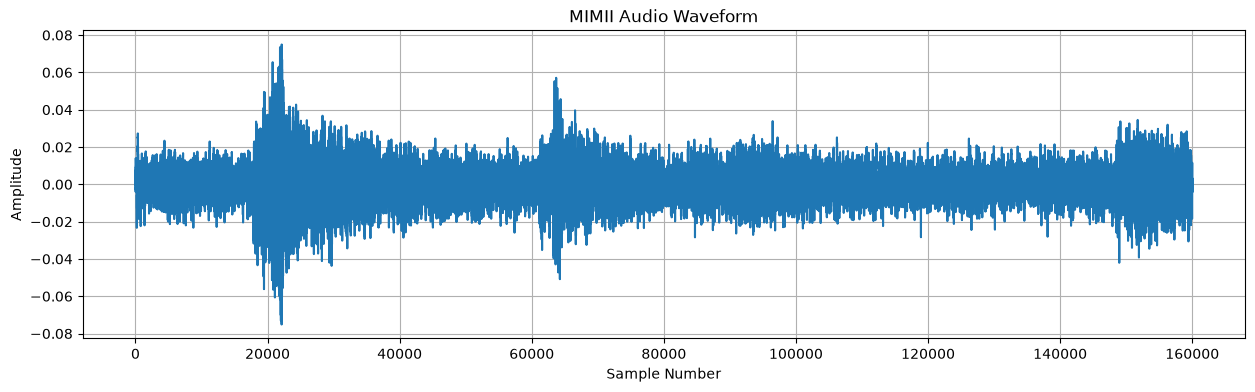

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(audio)

plt.title("MIMII Audio Waveform")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

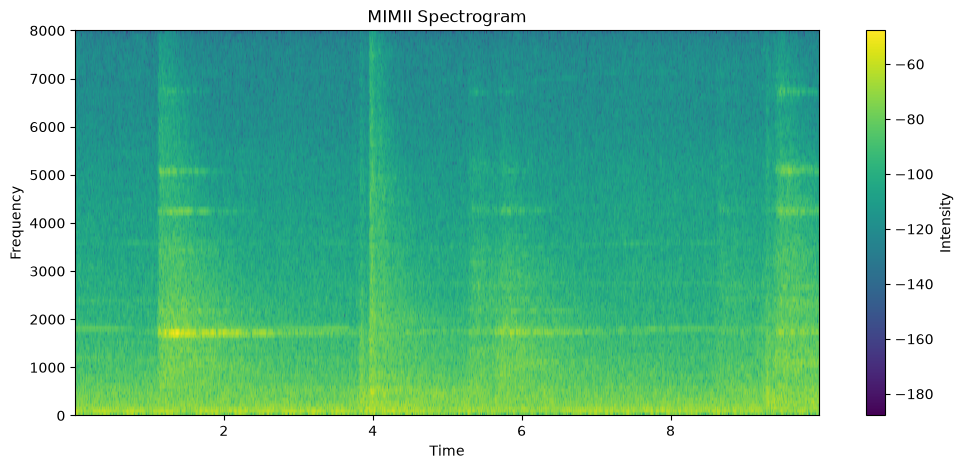

In [11]:
plt.figure(figsize=(12,5))

plt.specgram(audio, Fs=sample_rate, cmap="viridis")

plt.title("MIMII Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.colorbar(label="Intensity")

plt.show()

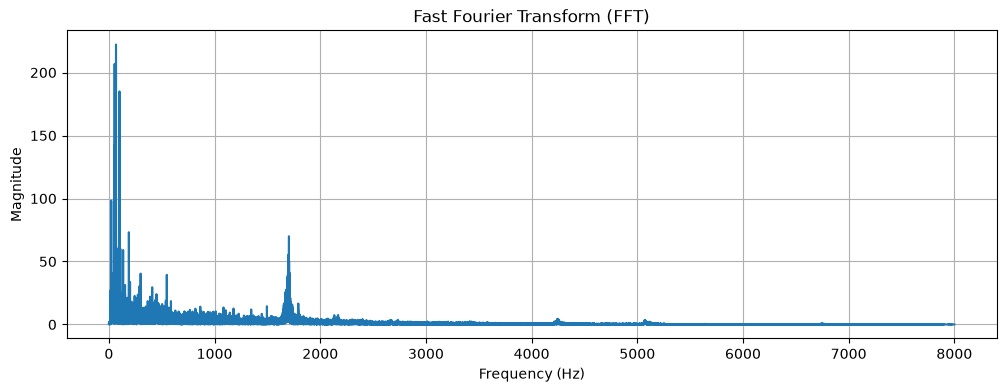

In [12]:
fft = np.abs(np.fft.rfft(audio))
freq = np.fft.rfftfreq(len(audio), 1/sample_rate)

plt.figure(figsize=(12,4))
plt.plot(freq, fft)

plt.title("Fast Fourier Transform (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.grid(True)
plt.show()

Root Mean Square (RMS): 0.009184900378459582


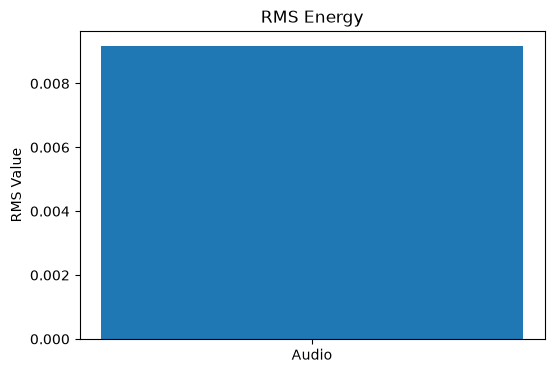

In [13]:
rms = np.sqrt(np.mean(audio**2))

print("Root Mean Square (RMS):", rms)

plt.figure(figsize=(6,4))
plt.bar(["Audio"], [rms])

plt.title("RMS Energy")
plt.ylabel("RMS Value")

plt.show()

In [18]:
labels = []

for file in audio_files:
    file_path = file.lower()

    # Check abnormal first
    if "abnormal" in file_path:
        labels.append("Abnormal")
    elif "normal" in file_path:
        labels.append("Normal")

label_df = pd.DataFrame({"Label": labels})

print(label_df["Label"].value_counts())

Label
Normal      2
Abnormal    2
Name: count, dtype: int64


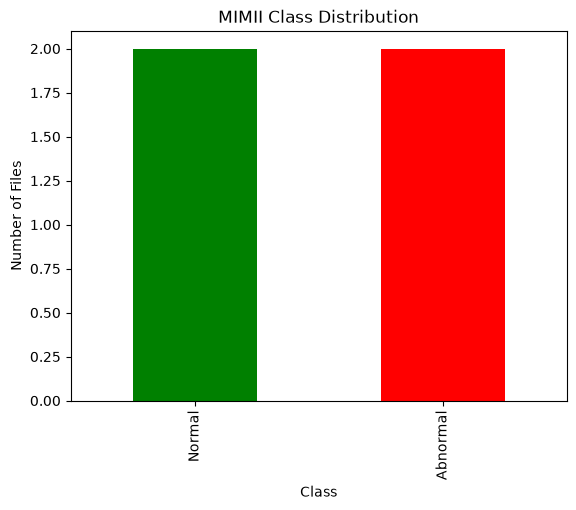

In [22]:
label_df["Label"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("MIMII Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Files")

plt.show()

In [21]:
import os
import numpy as np
import pandas as pd
import soundfile as sf

feature_list = []   

for file in audio_files:

    signal, sr = sf.read(file)
    if len(signal.shape) > 1:
        signal = signal.mean(axis=1)
    label = "Abnormal" if "abnormal" in file.lower() else "Normal"

    feature_list.append({
        "File": os.path.basename(file),
        "Label": label,
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Min": np.min(signal),
        "Max": np.max(signal),
        "RMS": np.sqrt(np.mean(signal**2)),
        "Duration": len(signal) / sr
    })

mimii_df = pd.DataFrame(feature_list)

print("Total files processed:", len(mimii_df))
mimii_df

Total files processed: 4


,File,Label,Mean,Std,Min,Max,RMS,Duration
0,00000008.wav.2uclsqfm.wav,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185,10.0
1,00000008.wav.2udc6roh.wav,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185,10.0
2,00000008.wav.2uclnsmg.wav,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520,10.0
3,00000008.wav.2uctplog.wav,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520,10.0


In [23]:
print("=== MIMII FEATURE DATA QUALITY ===")

print("Dataset shape:", mimii_df.shape)

print("\nMissing values:")
print(mimii_df.isnull().sum())

print("\nDuplicate rows:")
print(mimii_df.duplicated().sum())

print("\nInfinite values:")

numeric_cols = mimii_df.select_dtypes(include=np.number).columns

print(
    np.isinf(mimii_df[numeric_cols]).sum().sum()
)

print("\nFeature statistics:")
display(mimii_df.describe().T)

=== MIMII FEATURE DATA QUALITY ===
Dataset shape: (4, 8)

Missing values:
File        0
Label       0
Mean        0
Std         0
Min         0
Max         0
RMS         0
Duration    0
dtype: int64

Duplicate rows:
0

Infinite values:
0

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
Mean,4.0,0.000005,0.000003,0.000002,0.000002,0.000005,0.000008,0.000008
Std,4.0,0.010853,0.001926,0.009185,0.009185,0.010853,0.012520,0.012520
Min,4.0,-0.062057,0.015100,-0.075134,-0.075134,-0.062057,-0.048981,-0.048981
Max,4.0,0.064163,0.012457,0.053375,0.053375,0.064163,0.074951,0.074951
RMS,4.0,0.010853,0.001926,0.009185,0.009185,0.010853,0.012520,0.012520
Duration,4.0,10.000000,0.000000,10.000000,10.000000,10.000000,10.000000,10.000000


=== MIMII FEATURE CORRELATION ===


,Mean,Std,Min,Max,RMS,Duration
Mean,1.0,1.0,1.0,-1.0,1.0,NaN
Std,1.0,1.0,1.0,-1.0,1.0,NaN
Min,1.0,1.0,1.0,-1.0,1.0,NaN
Max,-1.0,-1.0,-1.0,1.0,-1.0,NaN
RMS,1.0,1.0,1.0,-1.0,1.0,NaN
Duration,NaN,NaN,NaN,NaN,NaN,NaN


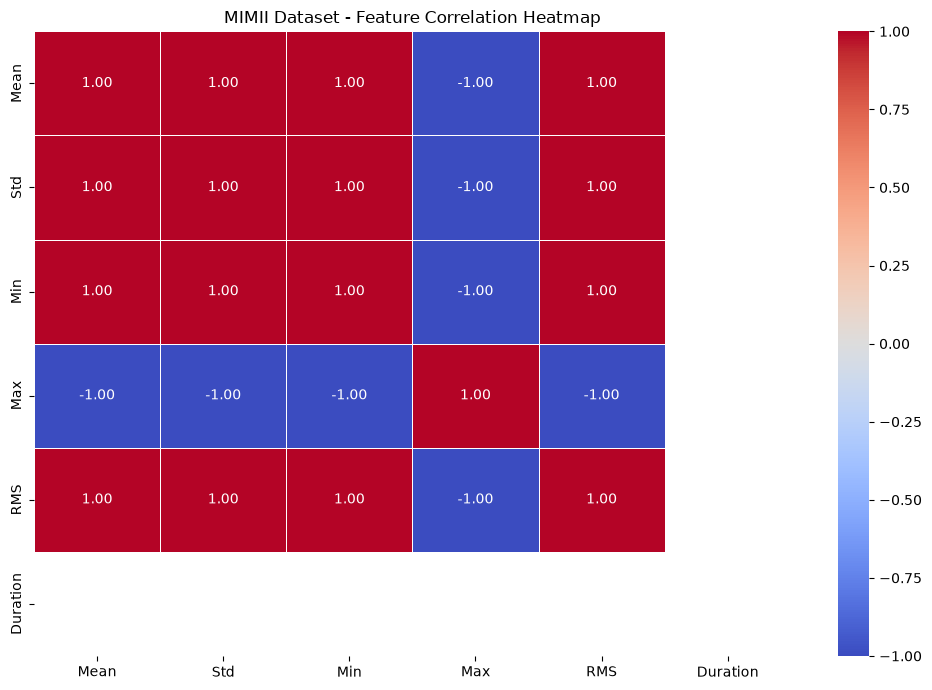

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features
mimii_numeric = mimii_df[
    [
        "Mean",
        "Std",
        "Min",
        "Max",
        "RMS",
        "Duration"
    ]
]

# Calculate correlation matrix
mimii_corr = mimii_numeric.corr()

print("=== MIMII FEATURE CORRELATION ===")
display(mimii_corr)

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    mimii_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("MIMII Dataset - Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [25]:
import os
import pandas as pd

# Processed data folder
processed_folder = r"C:\MachineHealthProject\processed"

# Create folder if needed
os.makedirs(processed_folder, exist_ok=True)

# Output path
mimii_output_path = os.path.join(
    processed_folder,
    "MIMII_processed.csv"
)

# Save processed dataset
mimii_df.to_csv(mimii_output_path, index=False)

print("=== MIMII DATASET SAVED ===")
print("File:", mimii_output_path)

# Verify the saved file
mimii_check = pd.read_csv(mimii_output_path)

print("\n=== SAVED FILE VERIFICATION ===")
print("Rows:", mimii_check.shape[0])
print("Columns:", mimii_check.shape[1])

print("\nColumns:")
print(list(mimii_check.columns))

print("\nLabels:")
print(mimii_check["Label"].value_counts())

print("\nFirst 4 rows:")
display(mimii_check)

=== MIMII DATASET SAVED ===
File: C:\MachineHealthProject\processed\MIMII_processed.csv

=== SAVED FILE VERIFICATION ===
Rows: 4
Columns: 8

Columns:
['File', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS', 'Duration']

Labels:
Label
Normal      2
Abnormal    2
Name: count, dtype: int64

First 4 rows:


,File,Label,Mean,Std,Min,Max,RMS,Duration
0,00000008.wav.2uclsqfm.wav,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185,10.0
1,00000008.wav.2udc6roh.wav,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185,10.0
2,00000008.wav.2uclnsmg.wav,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520,10.0
3,00000008.wav.2uctplog.wav,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520,10.0


In [26]:
# ============================================
# FINAL MIMII DATA QUALITY CHECK
# ============================================

print("=== FINAL MIMII QUALITY CHECK ===")

# 1. Missing values
print("\n1. Missing values:")
print(mimii_check.isnull().sum())

# 2. Infinite values in numeric columns
numeric_cols = mimii_check.select_dtypes(include="number").columns

print("\n2. Infinite values:")
print(
    np.isinf(mimii_check[numeric_cols].to_numpy()).sum()
)

# 3. Duplicate rows
print("\n3. Duplicate rows:")
print(mimii_check.duplicated().sum())

# 4. Class distribution
print("\n4. Class distribution:")
print(mimii_check["Label"].value_counts())

# 5. Feature ranges
print("\n5. Feature ranges:")
display(mimii_check[numeric_cols].describe().T)

# 6. Dataset shape
print("\n6. Final dataset shape:")
print(mimii_check.shape)

print("\n=== MIMII FINAL CHECK COMPLETE ===")

=== FINAL MIMII QUALITY CHECK ===

1. Missing values:
File        0
Label       0
Mean        0
Std         0
Min         0
Max         0
RMS         0
Duration    0
dtype: int64

2. Infinite values:
0

3. Duplicate rows:
0

4. Class distribution:
Label
Normal      2
Abnormal    2
Name: count, dtype: int64

5. Feature ranges:


,count,mean,std,min,25%,50%,75%,max
Mean,4.0,0.000005,0.000003,0.000002,0.000002,0.000005,0.000008,0.000008
Std,4.0,0.010853,0.001926,0.009185,0.009185,0.010853,0.012520,0.012520
Min,4.0,-0.062057,0.015100,-0.075134,-0.075134,-0.062057,-0.048981,-0.048981
Max,4.0,0.064163,0.012457,0.053375,0.053375,0.064163,0.074951,0.074951
RMS,4.0,0.010853,0.001926,0.009185,0.009185,0.010853,0.012520,0.012520
Duration,4.0,10.000000,0.000000,10.000000,10.000000,10.000000,10.000000,10.000000



6. Final dataset shape:
(4, 8)

=== MIMII FINAL CHECK COMPLETE ===
